`Импорт данных`

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score, max_error, mean_absolute_percentage_error, mean_absolute_error

from my_package.data_structurs import *
from my_package.utils import *
from my_package.approximation import *

In [2]:
csv_obj = CSVFilesObject('./././data/serias_from_images/csv_format/sup/', ',', False)

In [17]:
def get_mapping_from_dir(csv_object:CSVFilesObject):
    loader = MappingLoadersFromCSV(csv_object)
    
    all_mappings = {}

    for label, mapping in loader:
        all_mappings[label] = mapping

    return all_mappings

In [3]:
loader = MappingLoadersFromCSV(csv_obj)

visualizator = VisualizationPlots(
    (12, 9),
    'Визуализация кривых',
    True
)

### Визуализация начальных данных

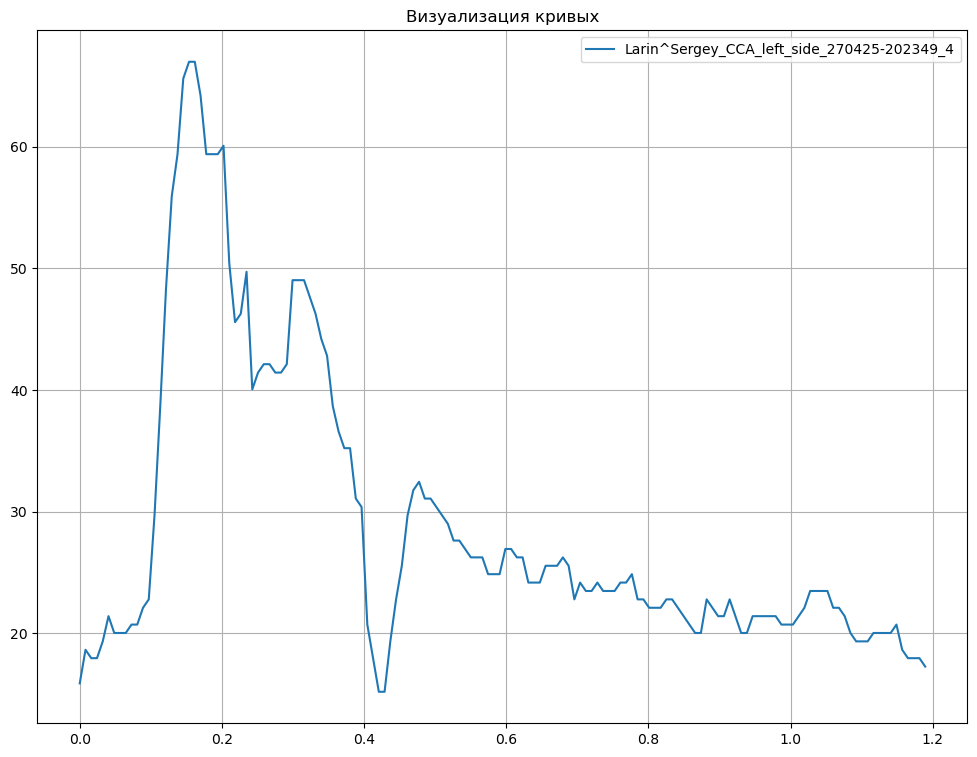

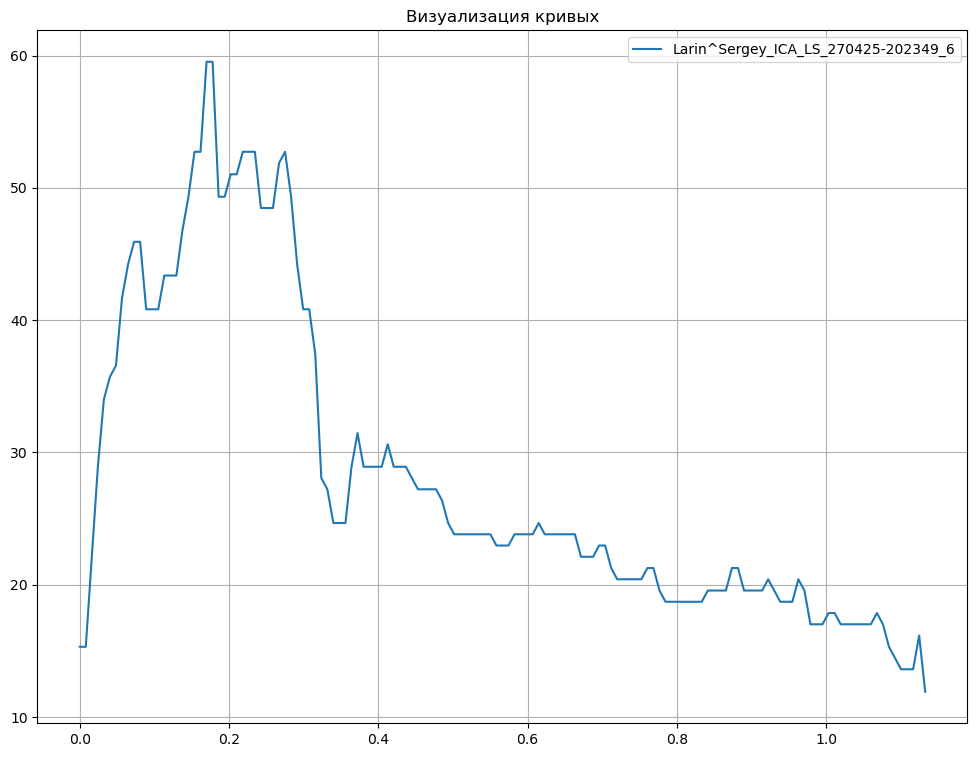

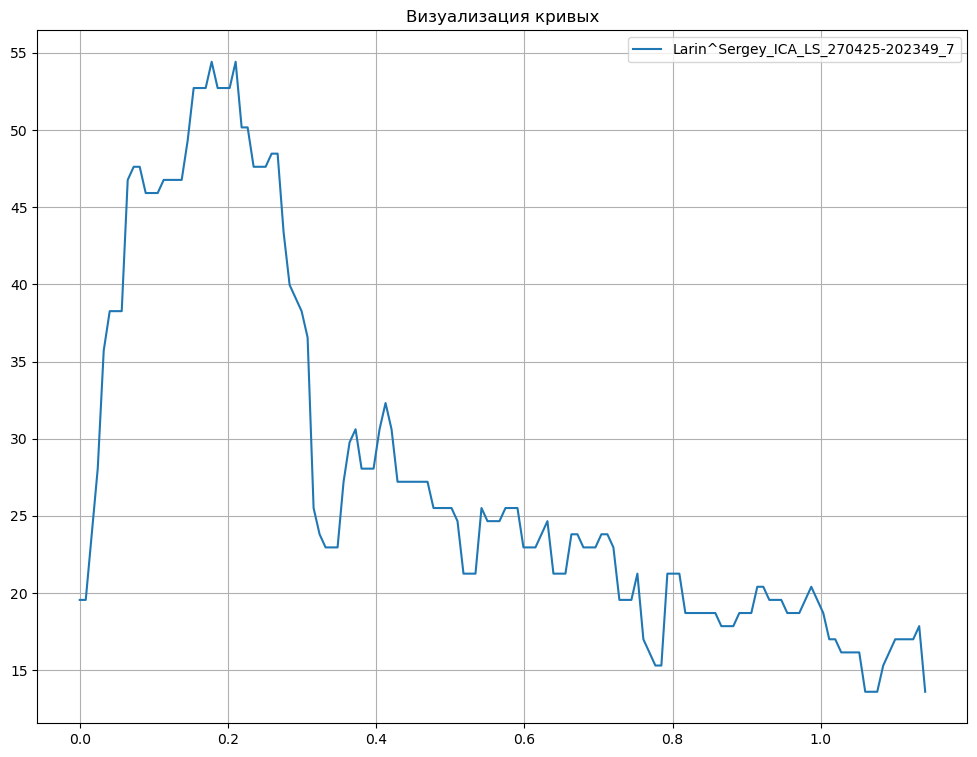

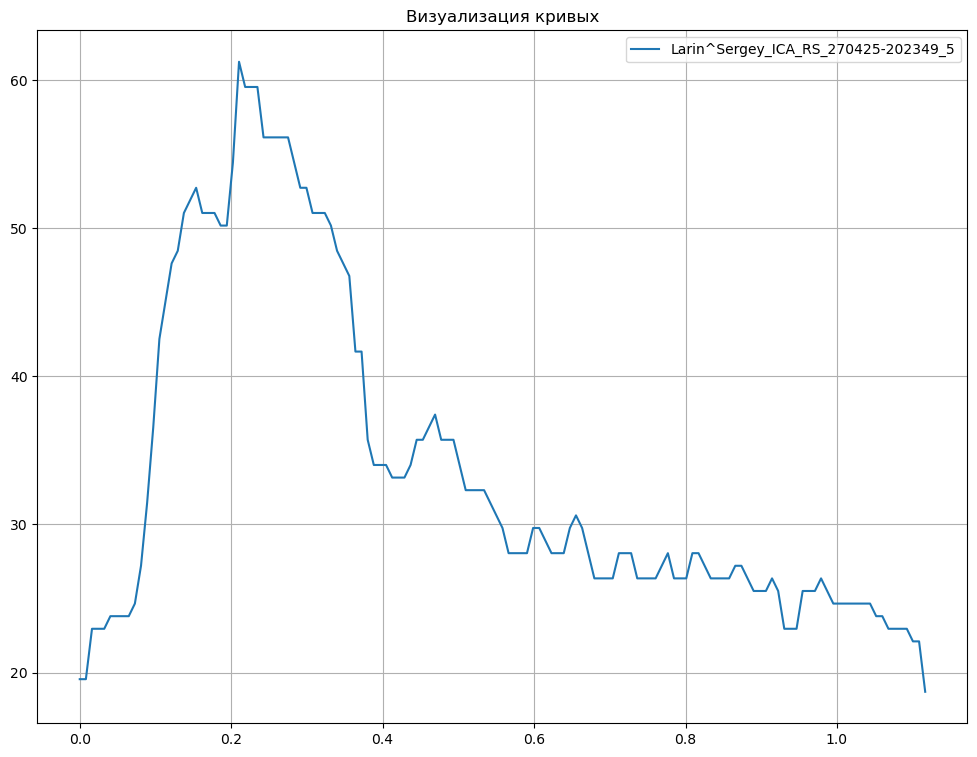

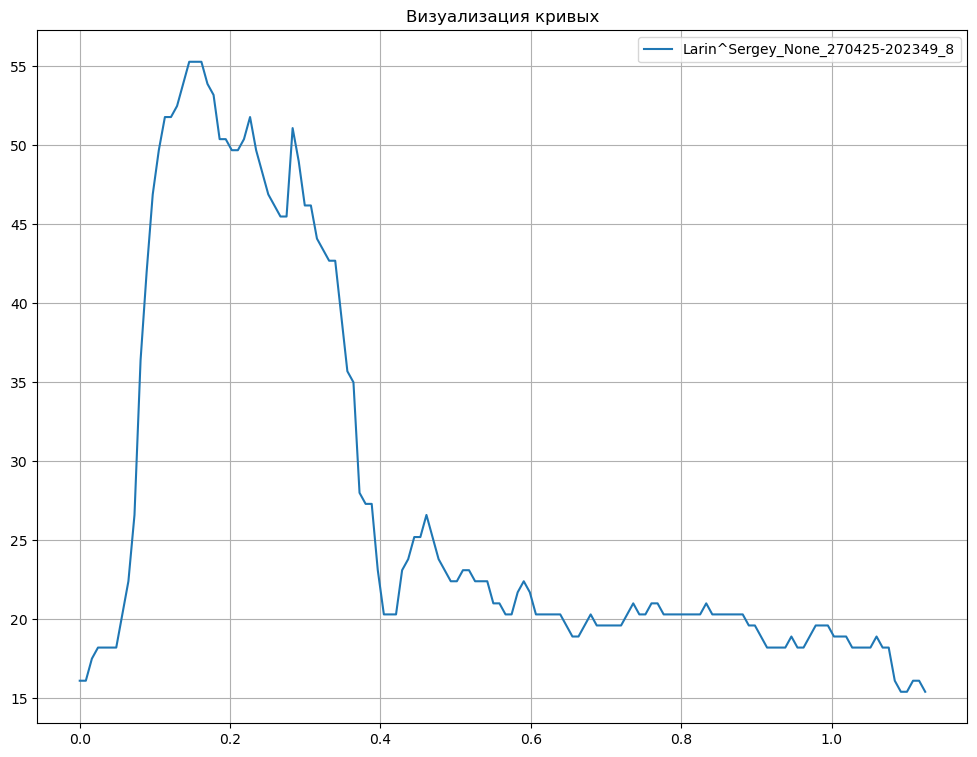

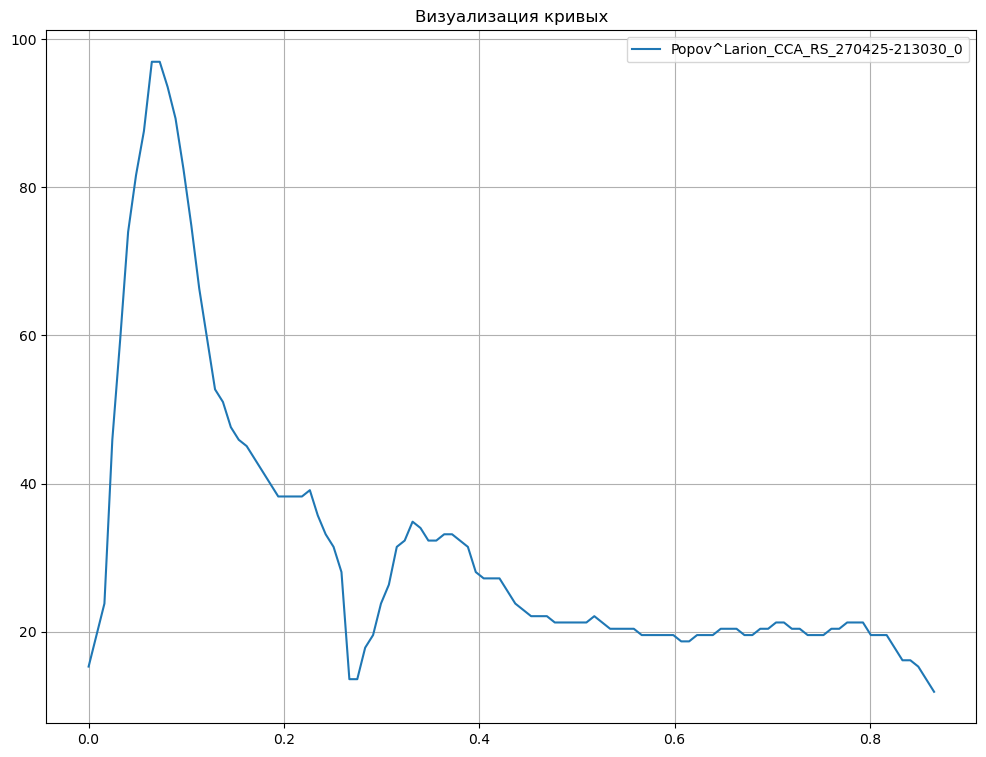

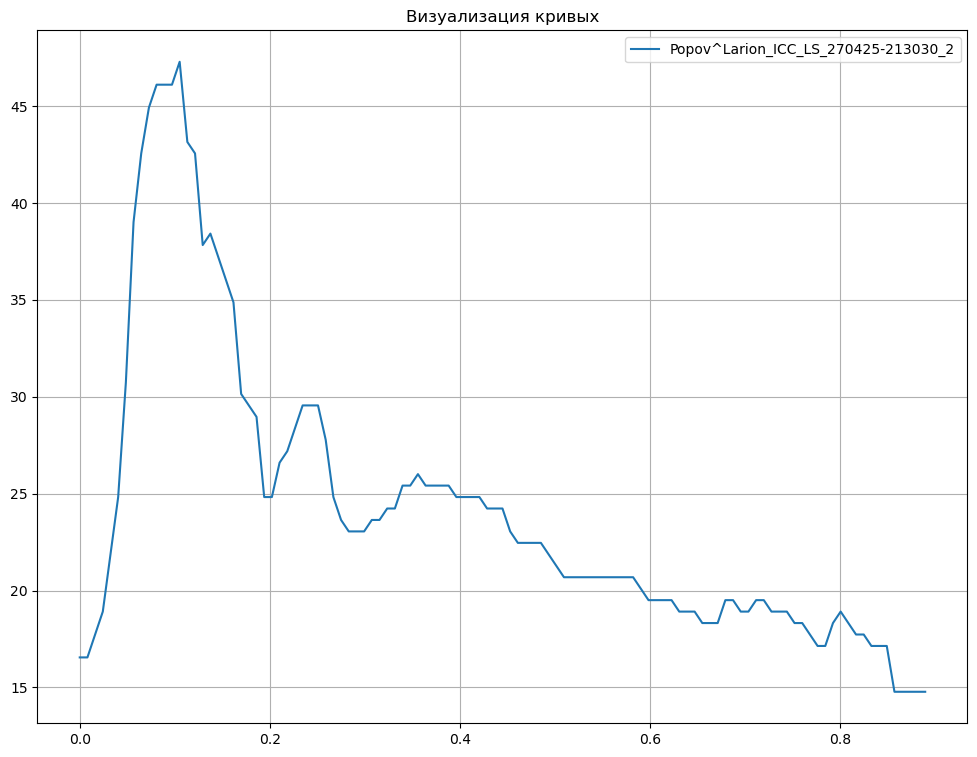

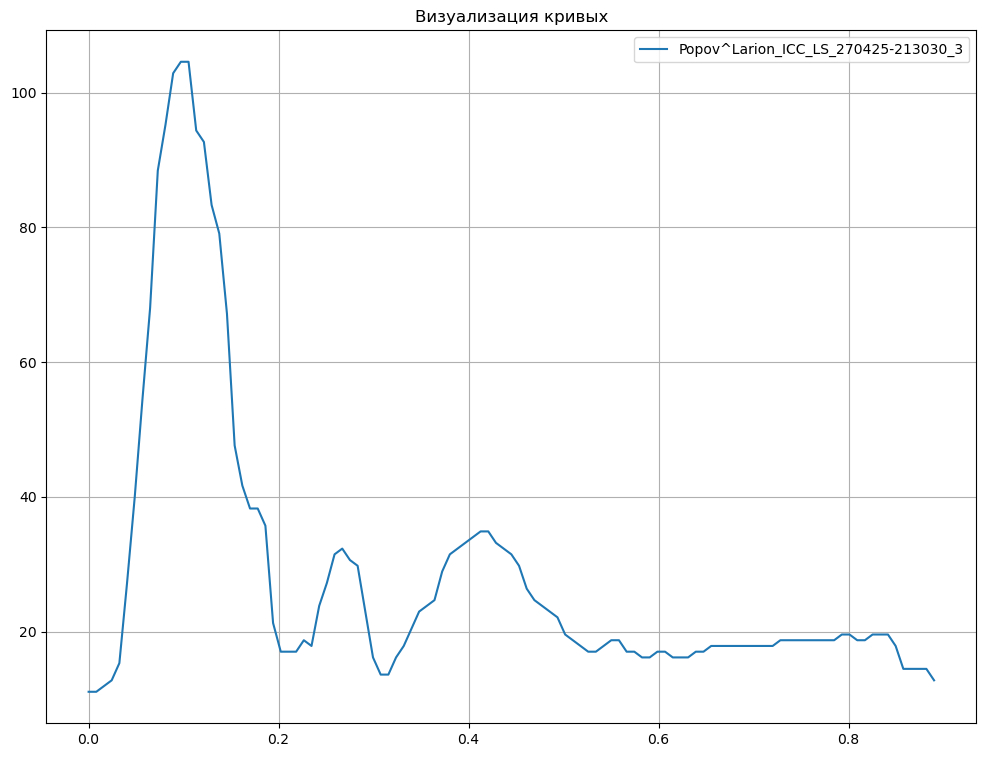

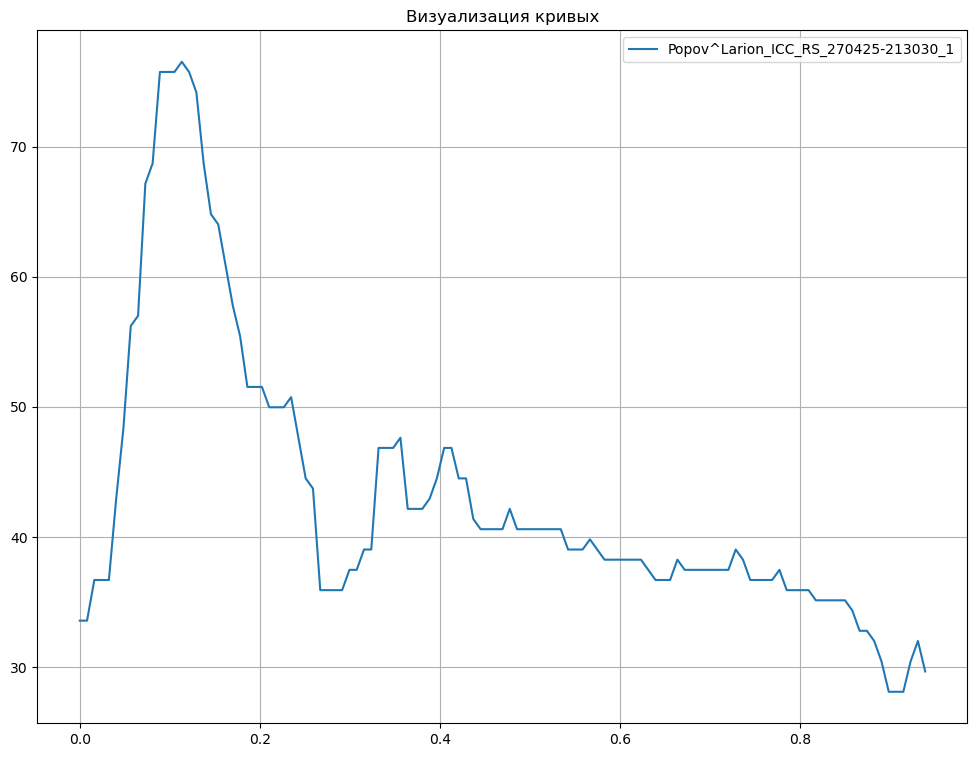

In [ ]:
for label, mapping in loader:
    visualizator.create_plot([mapping.get_x()], [mapping.get_y()], [label])

### Предварительная аппроксимация скользящим средним

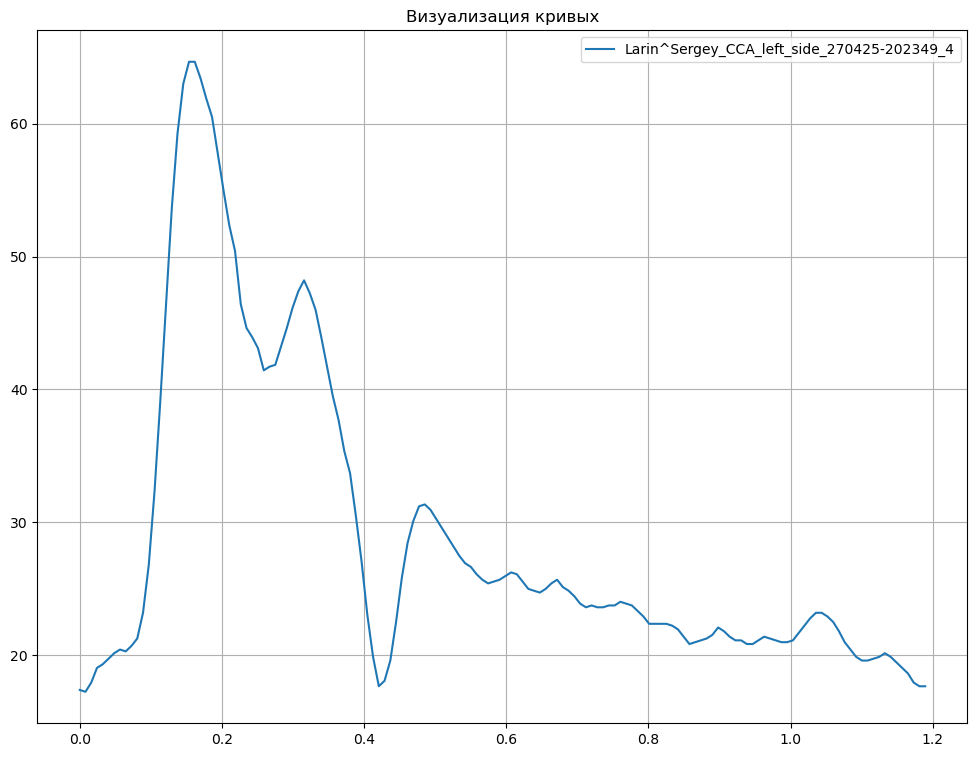

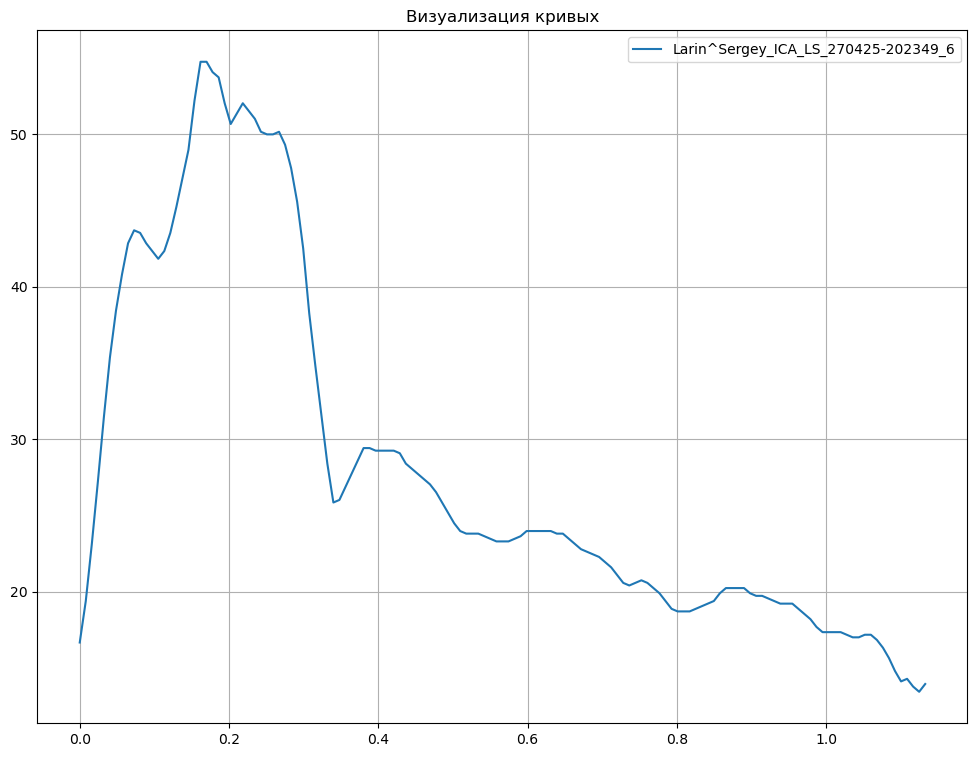

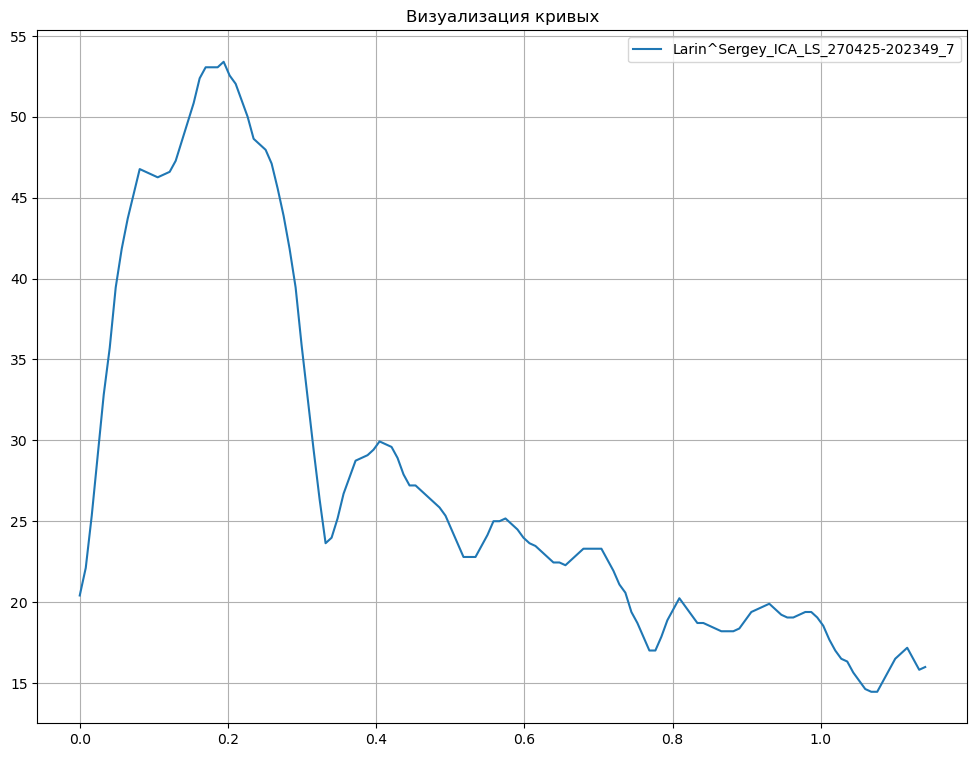

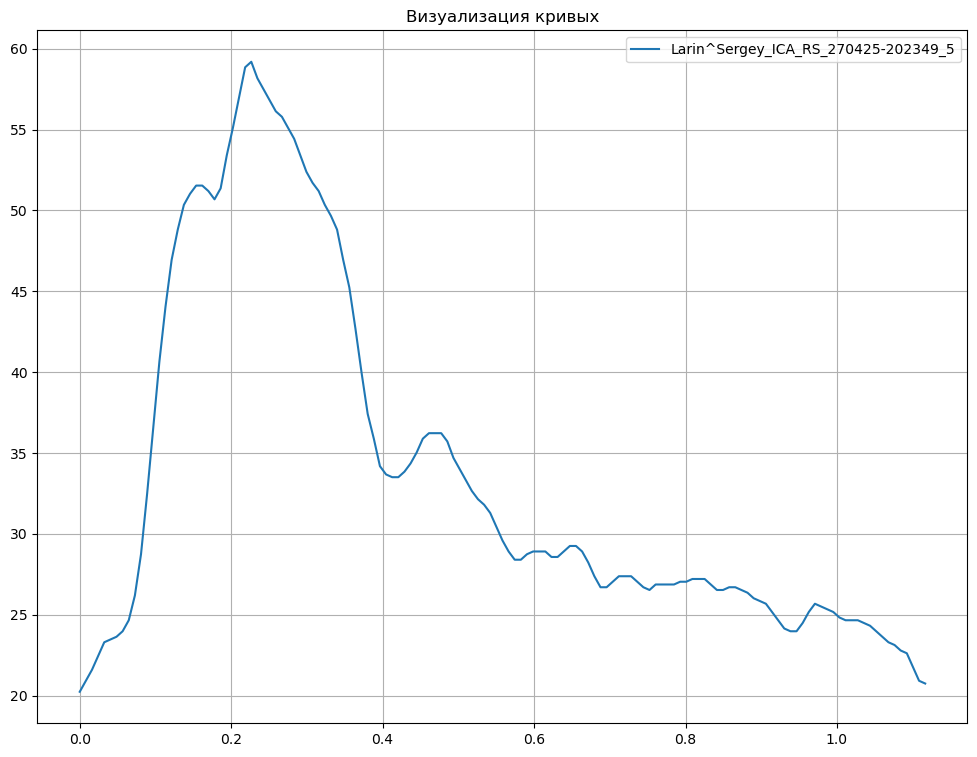

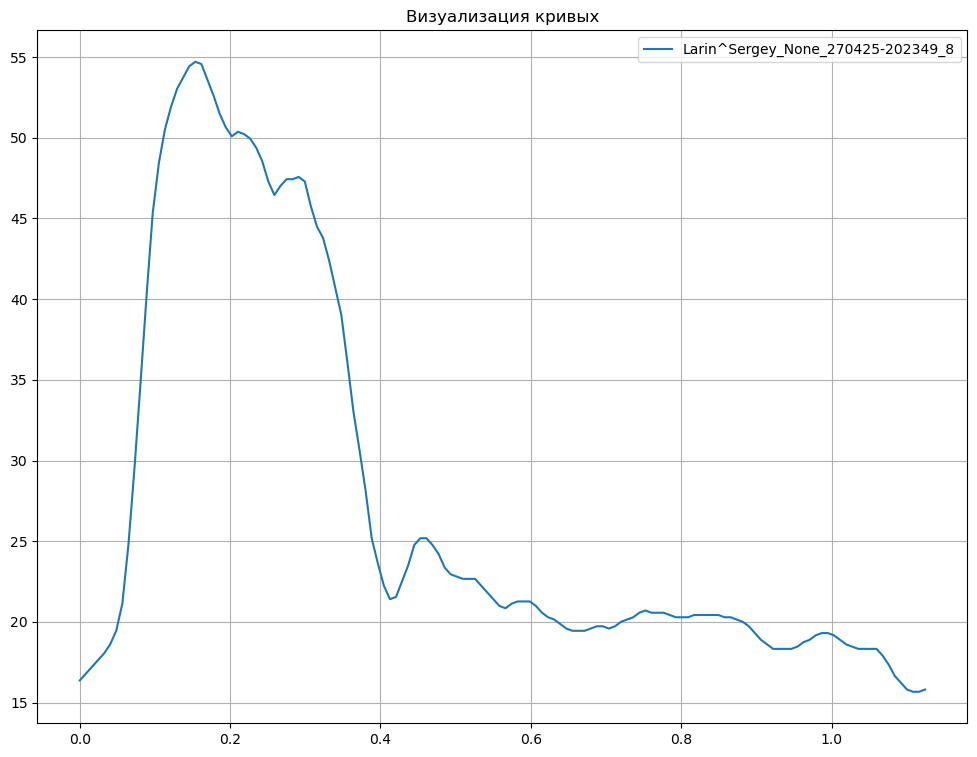

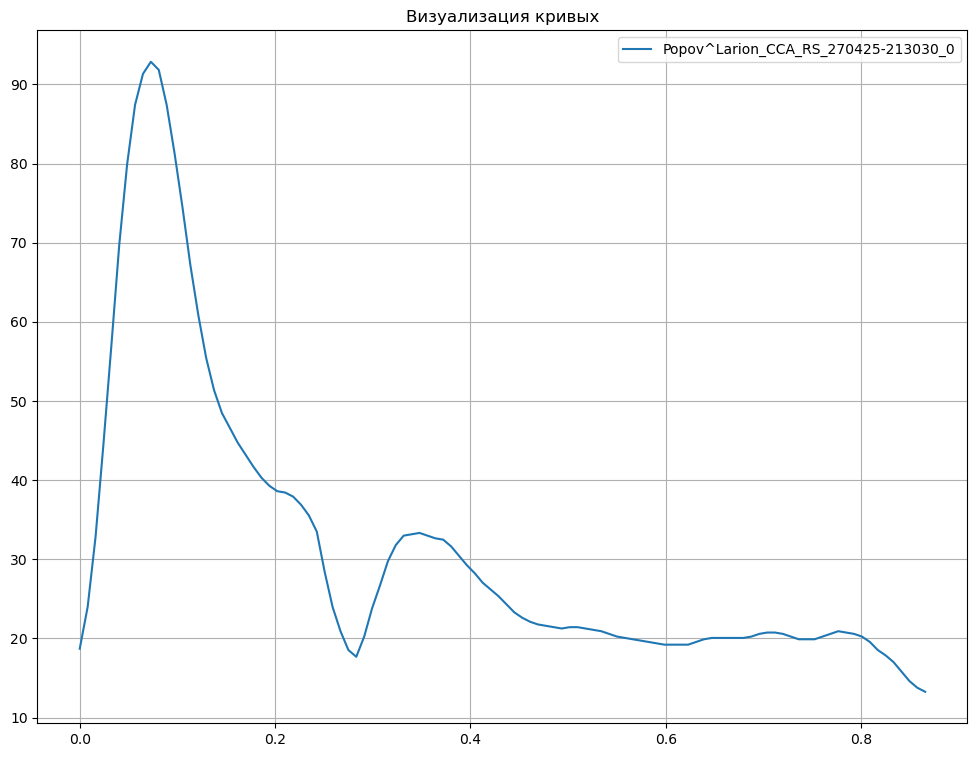

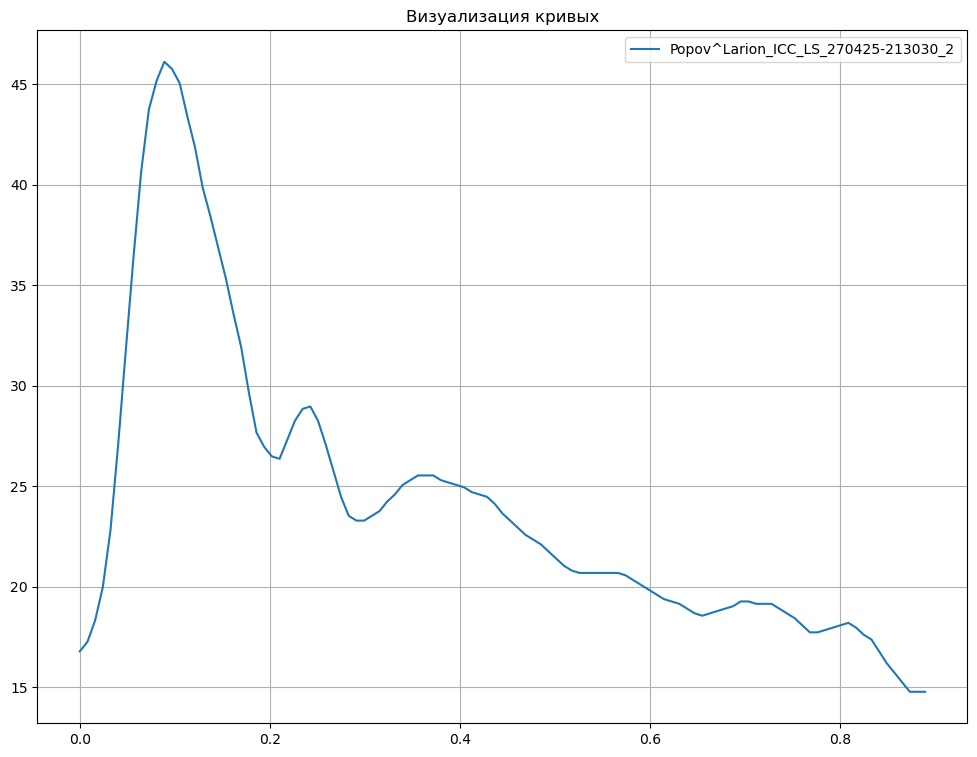

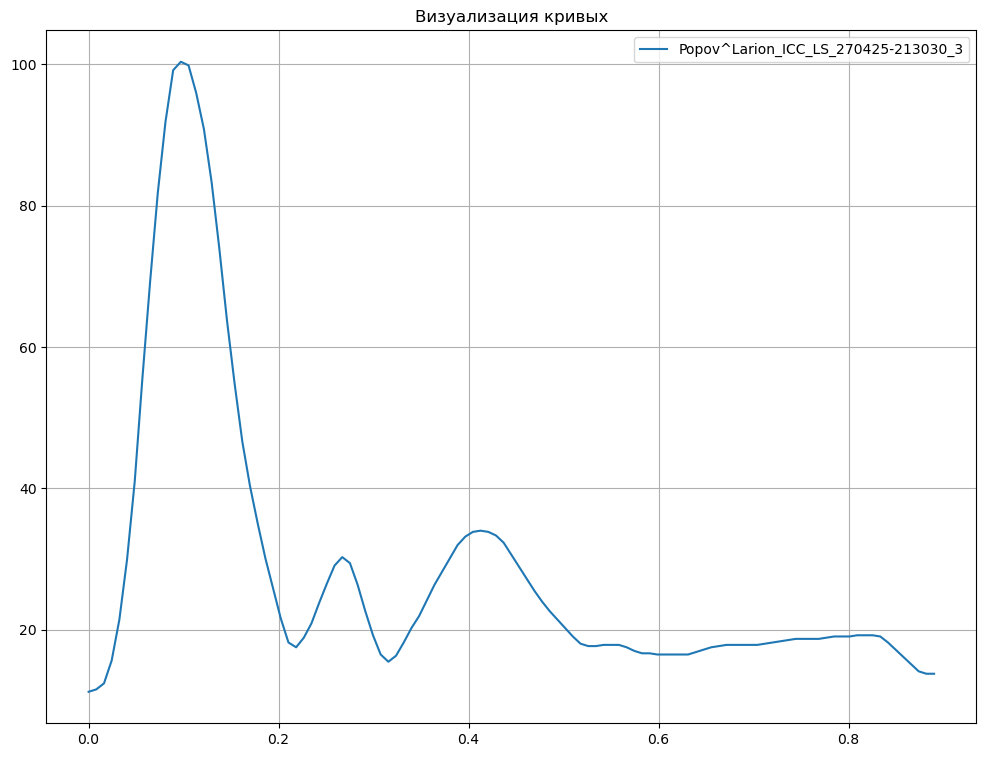

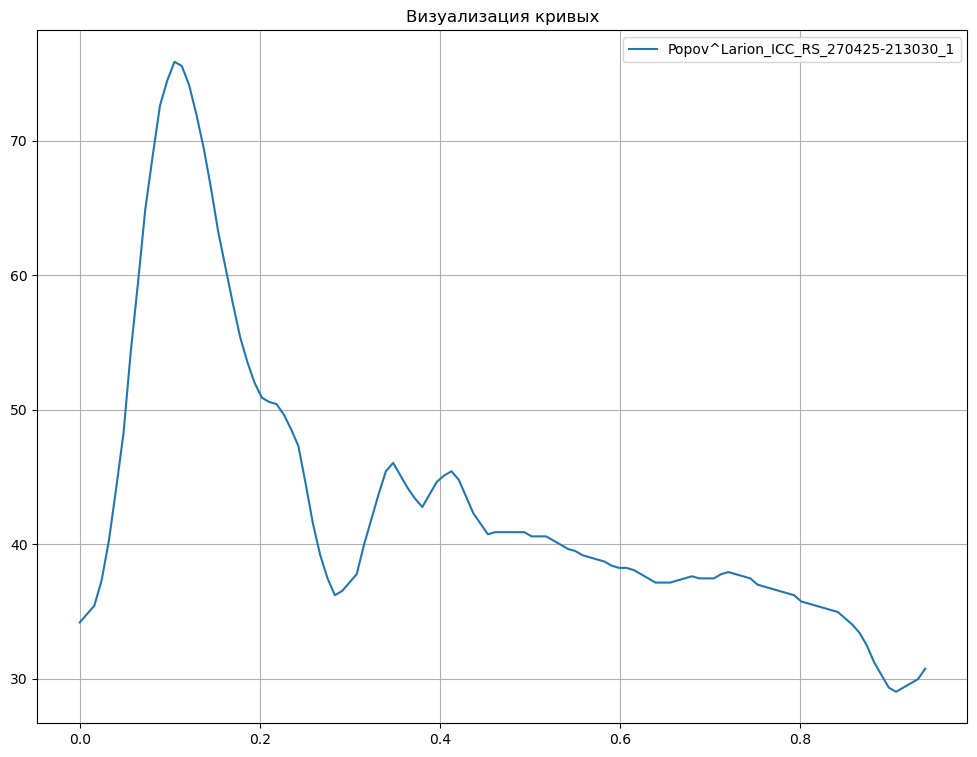

In [4]:
smooth_mappings = {}

for label, mapping in loader:
    smooth_mappings[label] = uniform_filter1d_for_mapping(mapping, 5)

    visualizator.create_plot([smooth_mappings[label].get_x()], [smooth_mappings[label].get_y()], [label])

### Кусочная аппроксимация сглажиного ряда

In [7]:
results_approx = {}

instructions = StructurePipelineApproximation(
    ['segment_1', 'segment_2', 'segment_3'],
    [lognormal_distribution for _ in range(3)],
    [[0, 0.35], [0.35, 0.65], [0.65, 1.5]],
    [(80, -1.9, 0.25, 10), (35, -0.8, 0.4, 5), (25, -0.29, 0.55, 2)],
    [([1, -3, 0.05, 0], [20, -0.5, 0.6, 30]), ([1, -1.5, 0.2, 0], [10, 0, 0.8, 20]), ([1, -1, 0.3, 0], [5, 0.5, 1.2, 10])]
)

for label, mapping in smooth_mappings.items():

    clear_mapping = preprocessing_pipeline(mapping)


    pipeline = PipelineLoader(clear_mapping, instructions)
    try:
        results_approx[label] = run_pipeline(pipeline)
    except:
        continue

ERRORS IN segment_1!
ERRORS IN segment_1!
ERRORS IN segment_1!
ERRORS IN segment_1!
ERRORS IN segment_1!
ERRORS IN segment_1!
ERRORS IN segment_1!
ERRORS IN segment_1!
ERRORS IN segment_1!


`Визуализация результата`

In [8]:
visualizator_result_approx = VisualizationPlots(
    (12, 9),
    'lognormal_distribution',
    True
)

for label, res in results_approx.items():
    visualizator_result_approx = VisualizationPlots(
        (12, 9),
        label,
        True
    )
    x = get_independent_values_sections(res)
    y_approx = get_values_piecewise_approximation(res)
    y_start = get_start_dependent_values(res)

    visualizator_result_approx.create_plot([x, x], [y_start, y_approx], ['start', 'approx'])

In [9]:
funcs_metrics = {
    'MAE': mean_absolute_error,
    'MAPE': mean_absolute_percentage_error,
    'R^2': r2_score,
    'C_norm': max_error
}

for label, mappings in results_approx.items():
    file_path_coeffs = rf'C:\Users\obyde\OneDrive\Рабочий стол\results\lognormal_distribution\coeff_tables\{label}.xlsx'
    file_path_errors = rf'C:\Users\obyde\OneDrive\Рабочий стол\results\lognormal_distribution\errors\{label}.xlsx'
    errors = pd.DataFrame()
    coeffs = pd.DataFrame()

    for section in mappings:
        coeffs = pd.concat([coeffs, section.parametres_show()])
        errors = pd.concat([errors, section.metrix_values_show(funcs_metrics)])

    coeffs.to_excel(file_path_coeffs)
    errors.to_excel(file_path_errors)

### Тест для конкретного ряда

In [5]:
smooth_mappings

{'Larin^Sergey_CCA_left_side_270425-202349_4': <my_package.data_structurs.base.Mapping at 0x149b6351310>,
 'Larin^Sergey_ICA_LS_270425-202349_6': <my_package.data_structurs.base.Mapping at 0x149b626b490>,
 'Larin^Sergey_ICA_LS_270425-202349_7': <my_package.data_structurs.base.Mapping at 0x149b62cb2f0>,
 'Larin^Sergey_ICA_RS_270425-202349_5': <my_package.data_structurs.base.Mapping at 0x149b63578a0>,
 'Larin^Sergey_None_270425-202349_8': <my_package.data_structurs.base.Mapping at 0x149b62c7d50>,
 'Popov^Larion_CCA_RS_270425-213030_0': <my_package.data_structurs.base.Mapping at 0x149b62db2f0>,
 'Popov^Larion_ICC_LS_270425-213030_2': <my_package.data_structurs.base.Mapping at 0x149b776a190>,
 'Popov^Larion_ICC_LS_270425-213030_3': <my_package.data_structurs.base.Mapping at 0x149b7817d10>,
 'Popov^Larion_ICC_RS_270425-213030_1': <my_package.data_structurs.base.Mapping at 0x149b63268e0>}

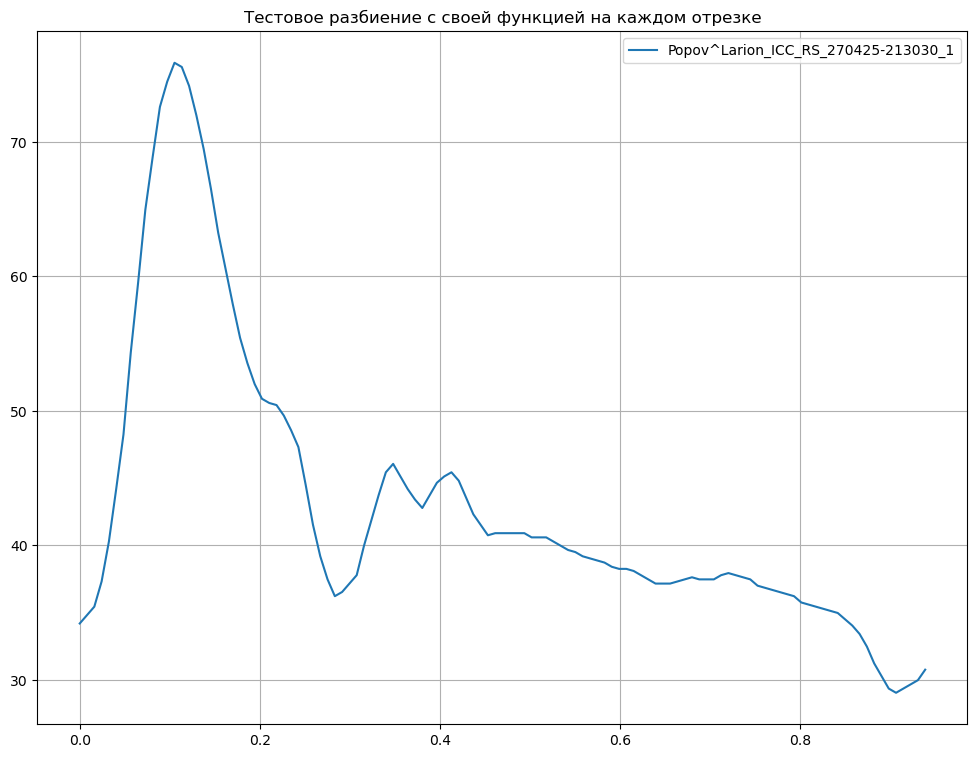

In [6]:
mapping = smooth_mappings['Popov^Larion_ICC_RS_270425-213030_1']
visualizator = VisualizationPlots(
    (12, 9), 
    'Тестовое разбиение с своей функцией на каждом отрезке', 
    True
)

visualizator.create_plot([mapping.get_x()], [mapping.get_y()], ['Popov^Larion_ICC_RS_270425-213030_1'])

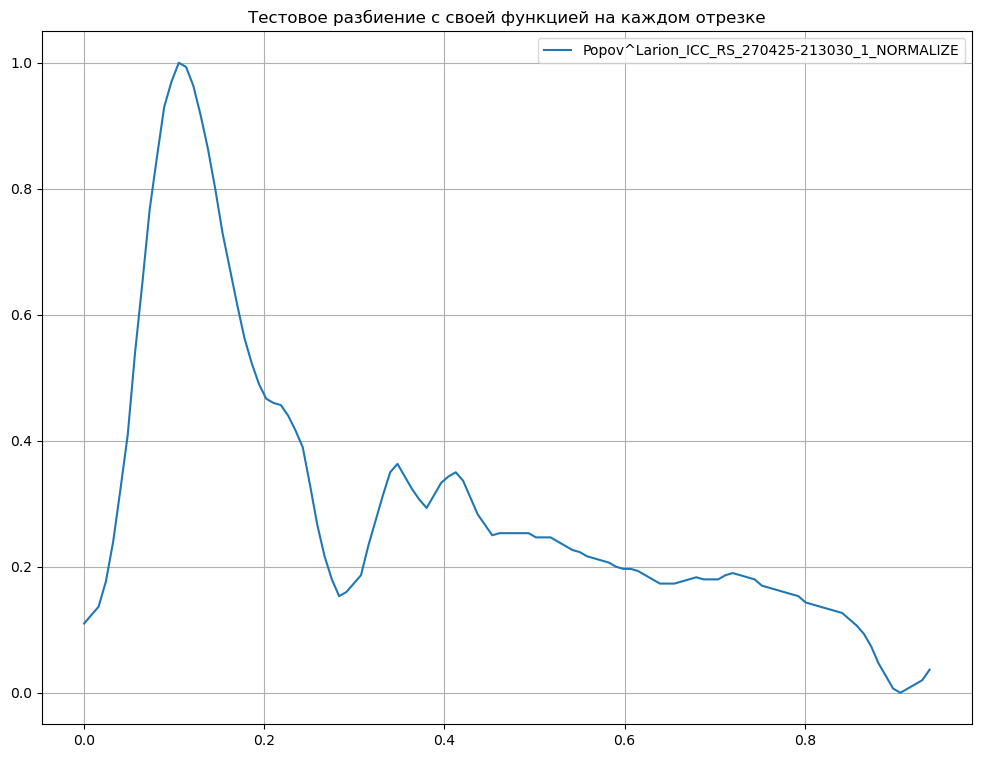

In [7]:
clear_mapping = preprocessing_pipeline(mapping)
normalize_obj = MinMaxNormalizeForMappings(clear_mapping)
normalize_mapping = normalize_obj.normalize()

visualizator.create_plot([normalize_mapping.get_x()], [normalize_mapping.get_y()], ['Popov^Larion_ICC_RS_270425-213030_1_NORMALIZE'])

instructions_for_LS_CCALS = StructurePipelineApproximation(
    ['lognormal_distribution_1', 'normal_distribution_1', 'lognormal_distribution_2', 'normal_distribution_2', 'inverse_exp_1'],
    [lognormal_distribution, normal_distribution, lognormal_distribution, normal_distribution, inverse_exponential],
    [[0, 0.2], [0.2, 0.36], [0.36, 0.4], [0.4, 0.485], [0.485, 1.5]],
    [(1, 0.25, -2.3, 0), (-0.5, 0.28, 1.49, 0.6), (0.5, -0.29, 0.55, 2)],
    [([1, -3, 0.05, 0], [20, -0.5, 0.6, 30]), ([1, -1.5, 0.2, 0], [10, 0, 0.8, 20]), ([1, -1, 0.3, 0], [5, 0.5, 1.2, 10])]
)

In [8]:
def get_values_piecewise_approximation(results_approx:list):
    all_values = np.array([])

    for res in results_approx:
        all_values = np.r_[all_values, res.mapping_result.get_y()]

    return all_values

def get_independent_values_sections(results_approx:list):
    all_values = np.array([])

    for res in results_approx:
        all_values = np.r_[all_values, res.mapping_start.get_x()]

    return all_values

def get_start_dependent_values(results_approx:list):
    all_values = np.array([])

    for res in results_approx:
        all_values = np.r_[all_values, res.mapping_start.get_y()]

    return all_values

# -----------------------------------------------------------------------------------------------

def get_piecewise_mapping(results_approx:list):
    mappings = []

    for res in results_approx:
        mappings.append(res.mapping_result)

    return mappings

def denormalize_result_approx_struct(
        result_approx:ResultsApproximatingFunction,
        start_mapping_normalize_obj:MinMaxNormalizeForMappings
):
    denormalize_result = ResultsApproximatingFunction(
        start_mapping_normalize_obj.denormalize(result_approx.mapping_start),
        start_mapping_normalize_obj.denormalize(result_approx.mapping_result),
        result_approx.func,
        result_approx.params,
        result_approx.bounds_parametres
    )
    return denormalize_result

In [9]:
funcs_metrics = {
    'MAE': mean_absolute_error,
    'MAPE': mean_absolute_percentage_error,
    'R^2': r2_score,
    'C_norm': max_error
}

instructions = StructurePipelineApproximation(
    [f'lognormal distribution {i}' for i in range(7)],
    [inverse_exponential for _ in range(7)],
    [[0, 0.2], [0.2, 0.25], [0.25, 0.31], [0.31, 0.388], [0.388, 0.43], [0.43, 0.63], [0.63, 1.5]],
    [(1, -0.1, 0.1), (-0.5, -0.25, 0.6), (0.5, -0.345, 0.5), (-1, -0.415, 0.25), (1, -0.51, 0.1), (1, -0.75, 0.1), (1, -0.75, 0.1)],
    [([-5, -1.5, -1], [5, 1.5, 1]), ([-5, -1.5, -1], [5, 1.5, 1]), ([-5, -1.5, -1], [5, 1.5, 1]), ([-5, -1.5, -1], [5, 1.5, 1]), ([-5, -1.5, -1], [5, 1.5, 1]), ([-5, -1.5, -1], [5, 1.5, 1]), ([-5, -1.5, -1], [5, 1.5, 1])]
)

pipeline = PipelineLoader(normalize_mapping, instructions)
result = run_pipeline(pipeline)

result_denormalize = [denormalize_result_approx_struct(res, normalize_obj) for res in result]

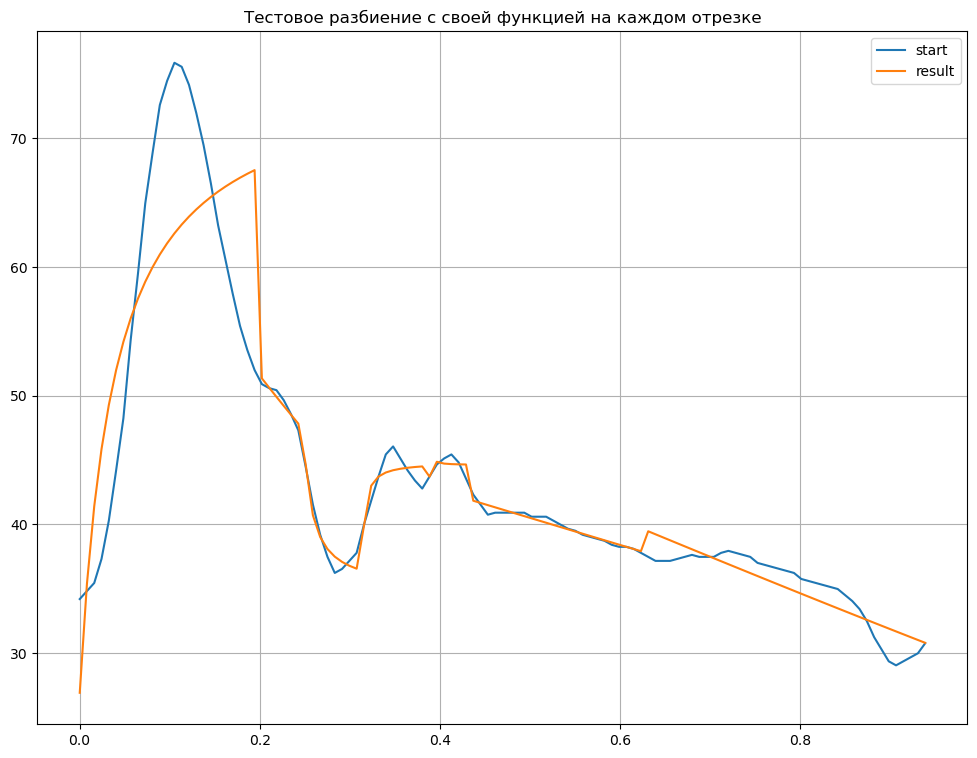

----------------------SEGMENT_0----------------------
Condition normalize = False
----------------------SEGMENT_1----------------------
Condition normalize = False
----------------------SEGMENT_2----------------------
Condition normalize = False
----------------------SEGMENT_3----------------------
Condition normalize = False
----------------------SEGMENT_4----------------------
Condition normalize = False
----------------------SEGMENT_5----------------------
Condition normalize = False
----------------------SEGMENT_6----------------------
Condition normalize = False


In [10]:
visualizator.create_plot_mapping([clear_mapping, Mapping(get_independent_values_sections(result_denormalize), get_values_piecewise_approximation(result_denormalize), False)], ['start', 'result'])

all_errors = pd.DataFrame()
all_parametres_info = pd.DataFrame()

for i, res in enumerate(result_denormalize):
    # visualizator.create_plot_result_approx(res, [f'section {i} start', f'section {i} result'])
    print(f'----------------------SEGMENT_{i}----------------------')
    all_parametres_info = pd.concat([all_parametres_info, res.parametres_show()])
    all_errors = pd.concat([all_errors, res.metrix_values_show(funcs_metrics)])

all_errors.to_excel('all_sections_errors.xlsx')
all_parametres_info.to_excel('all_parametres_info.xlsx')